# 🔧 QE Analysis Toolkit — `analyze_qe()`

**Quick Navigation:**
- [📊 Plotting Electronic Band Structures](#bands)
- [🌀 Plotting Density of States (PDOS)](#pdos)
- [📈 Plotting Convergence Tests](#convergence)
- [🌈 Plotting Optical Properties](#optics)

> **Reminder:** Copy the relevant output files into this notebook's folder before running any cell below.

<a id="bands"></a>
## 📊 Plotting Electronic Band Structures

**Data file needed:** `.gnu` file (e.g., `bands.dat.gnu`)

### Quick Look
Just check if the bands look right — pass the filename, action, and Fermi energy:
```python
analyze_qe("bands.dat.gnu", "bands", e_fermi=-5.3089)
```

### Publication-Ready Plot
Limit the Y-axis to the band gap region, add high-symmetry k-point labels, and save as an image:
```python
nodes = [0.0000, 0.6667, 1.0000, 1.5774]
labels = [r'$\Gamma$', 'K', 'M', r'$\Gamma$']

analyze_qe("bands.dat.gnu", "bands", e_fermi=-5.3089, ylim=[-4, 4],
           k_nodes=nodes, k_labels=labels, save_as="publication_bands.png")
```

**Parameters:**
| Param | Meaning |
|---|---|
| `e_fermi` | Fermi energy (shifts bands to E=0) |
| `ylim` | Y-axis energy window |
| `k_nodes` | Fractional positions of high-symmetry points |
| `k_labels` | Labels for high-symmetry points (LaTeX supported) |
| `save_as` | Output image filename |

Loading QE band data from ./ep1_bands/bands.dat.gnu...

 Band Gap Information
VBM :  -0.866200 eV
CBM :   0.793900 eV
Gap :   1.660100 eV

-> Plot successfully saved as 'bands.png'


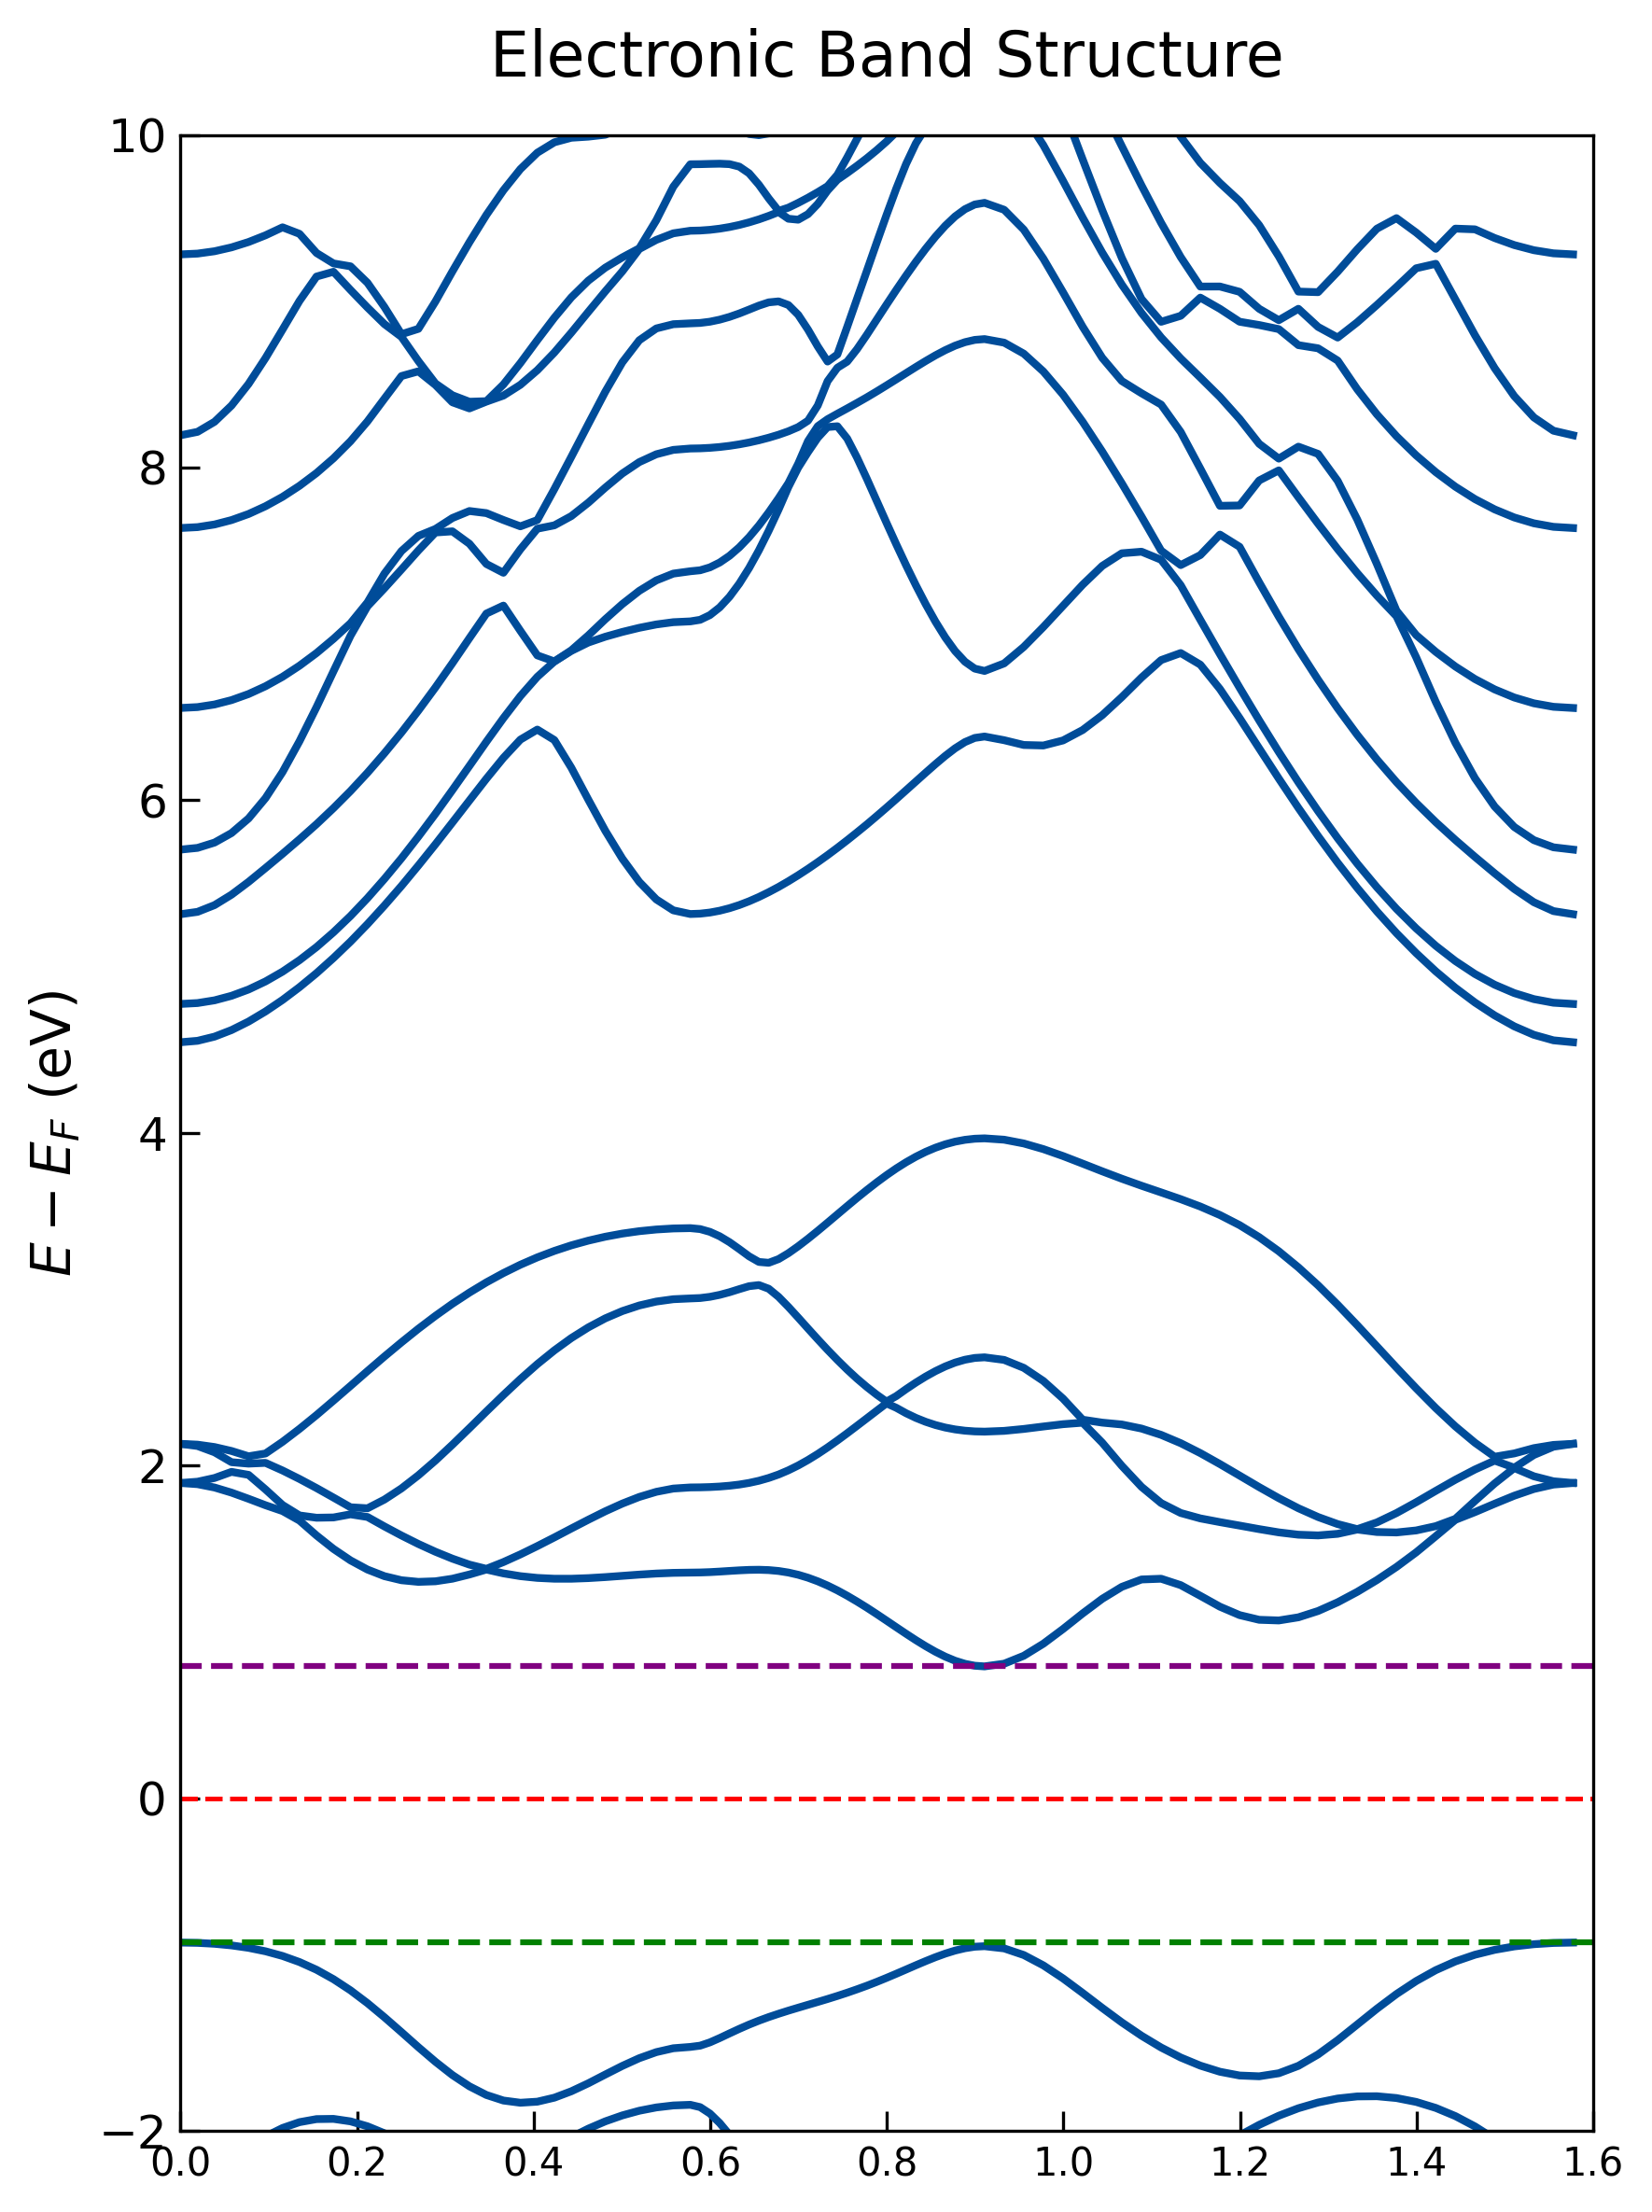

In [1]:
from workshop_tools import analyze_qe
analyze_qe("./ep1_bands/bands.dat.gnu", "bandsnew", e_fermi=-0.1900, xlim=[0, 1.6], ylim=[-2, 10], save_as="bands.png", gap_window=2.0)

Loading QE band data from ./ep1_bands/bands.dat.gnu...

 Band Gap Information
VBM :  -1.328700 eV
CBM :   0.331400 eV
Gap :   1.660100 eV

-> Plot successfully saved as 'bands.png'


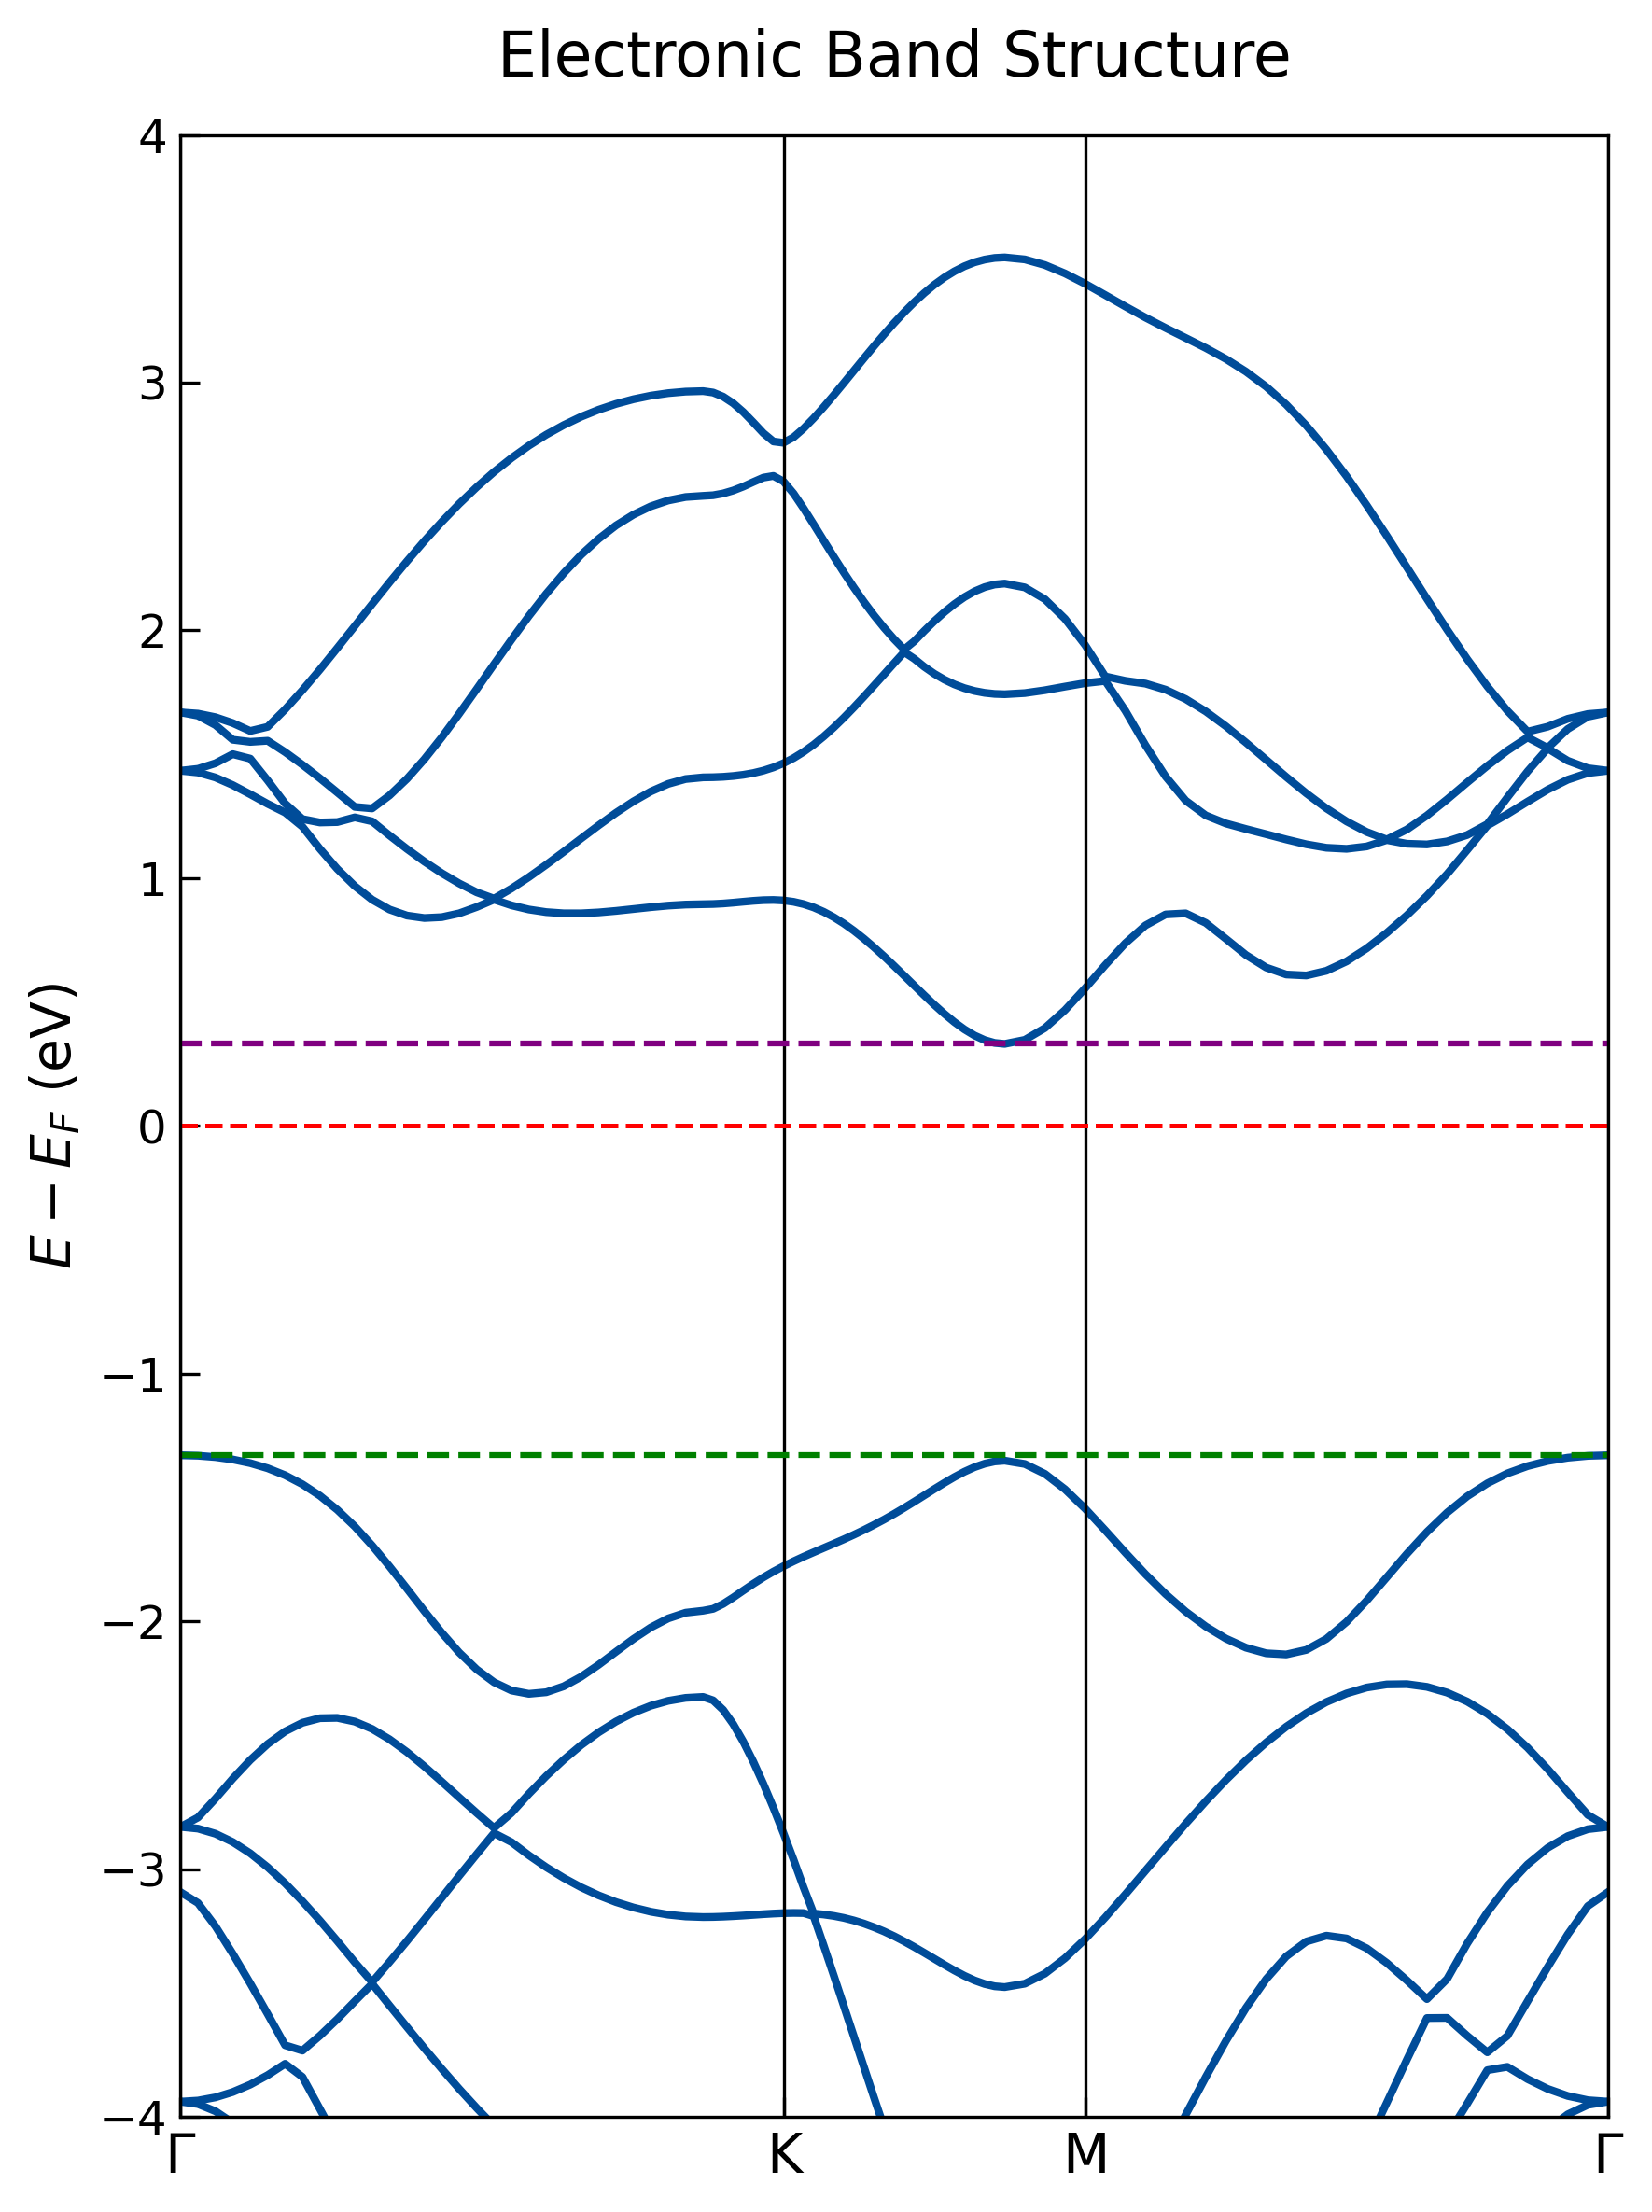

In [3]:
from workshop_tools import analyze_qe
nodes = [0.0000, 0.6667, 1.0000, 1.5774]
labels = [r'$\Gamma$', 'K', 'M', r'$\Gamma$']
analyze_qe("./ep1_bands/bands.dat.gnu", "bandsnew", e_fermi=0.2725, xlim=[0, 1.5774], ylim=[-4, 4], k_nodes=nodes, k_labels=labels,  save_as="bands.png", gap_window=2.0)

<a id="pdos"></a>
## 🌀 Plotting Density of States (PDOS)

**Data file needed:** PDOS files generated by `projwfc.x` (e.g., `mo_s_pdos.pdos_atm#1(mo)_wfc#1(s)`)

Pass just the **prefix** (not the full filename) — the tool auto-detects all matching atomic/orbital files, sums subshells per atom, and plots atom-wise PDOS:

```python
analyze_qe("mo_s_pdos", "pdos", e_fermi=-5.1089, xlim=[-0.5, 0.5], save_as="pdos_plot.png")
```

**Parameters:**
| Param | Meaning |
|---|---|
| `e_fermi` | Fermi energy reference |
| `xlim` | Energy window to display |
| `save_as` | Output image filename |

> ⚠️ Note: use the file **prefix** before `.pdos_atm#...`, not the full filename.

Searching for PDOS files with prefix './ep3_dos_pdos/MoS2'...
-> Found Total DOS file: ./ep3_dos_pdos\MoS2.pdos_tot
-> Plot successfully saved as 'pdos_plot.png'


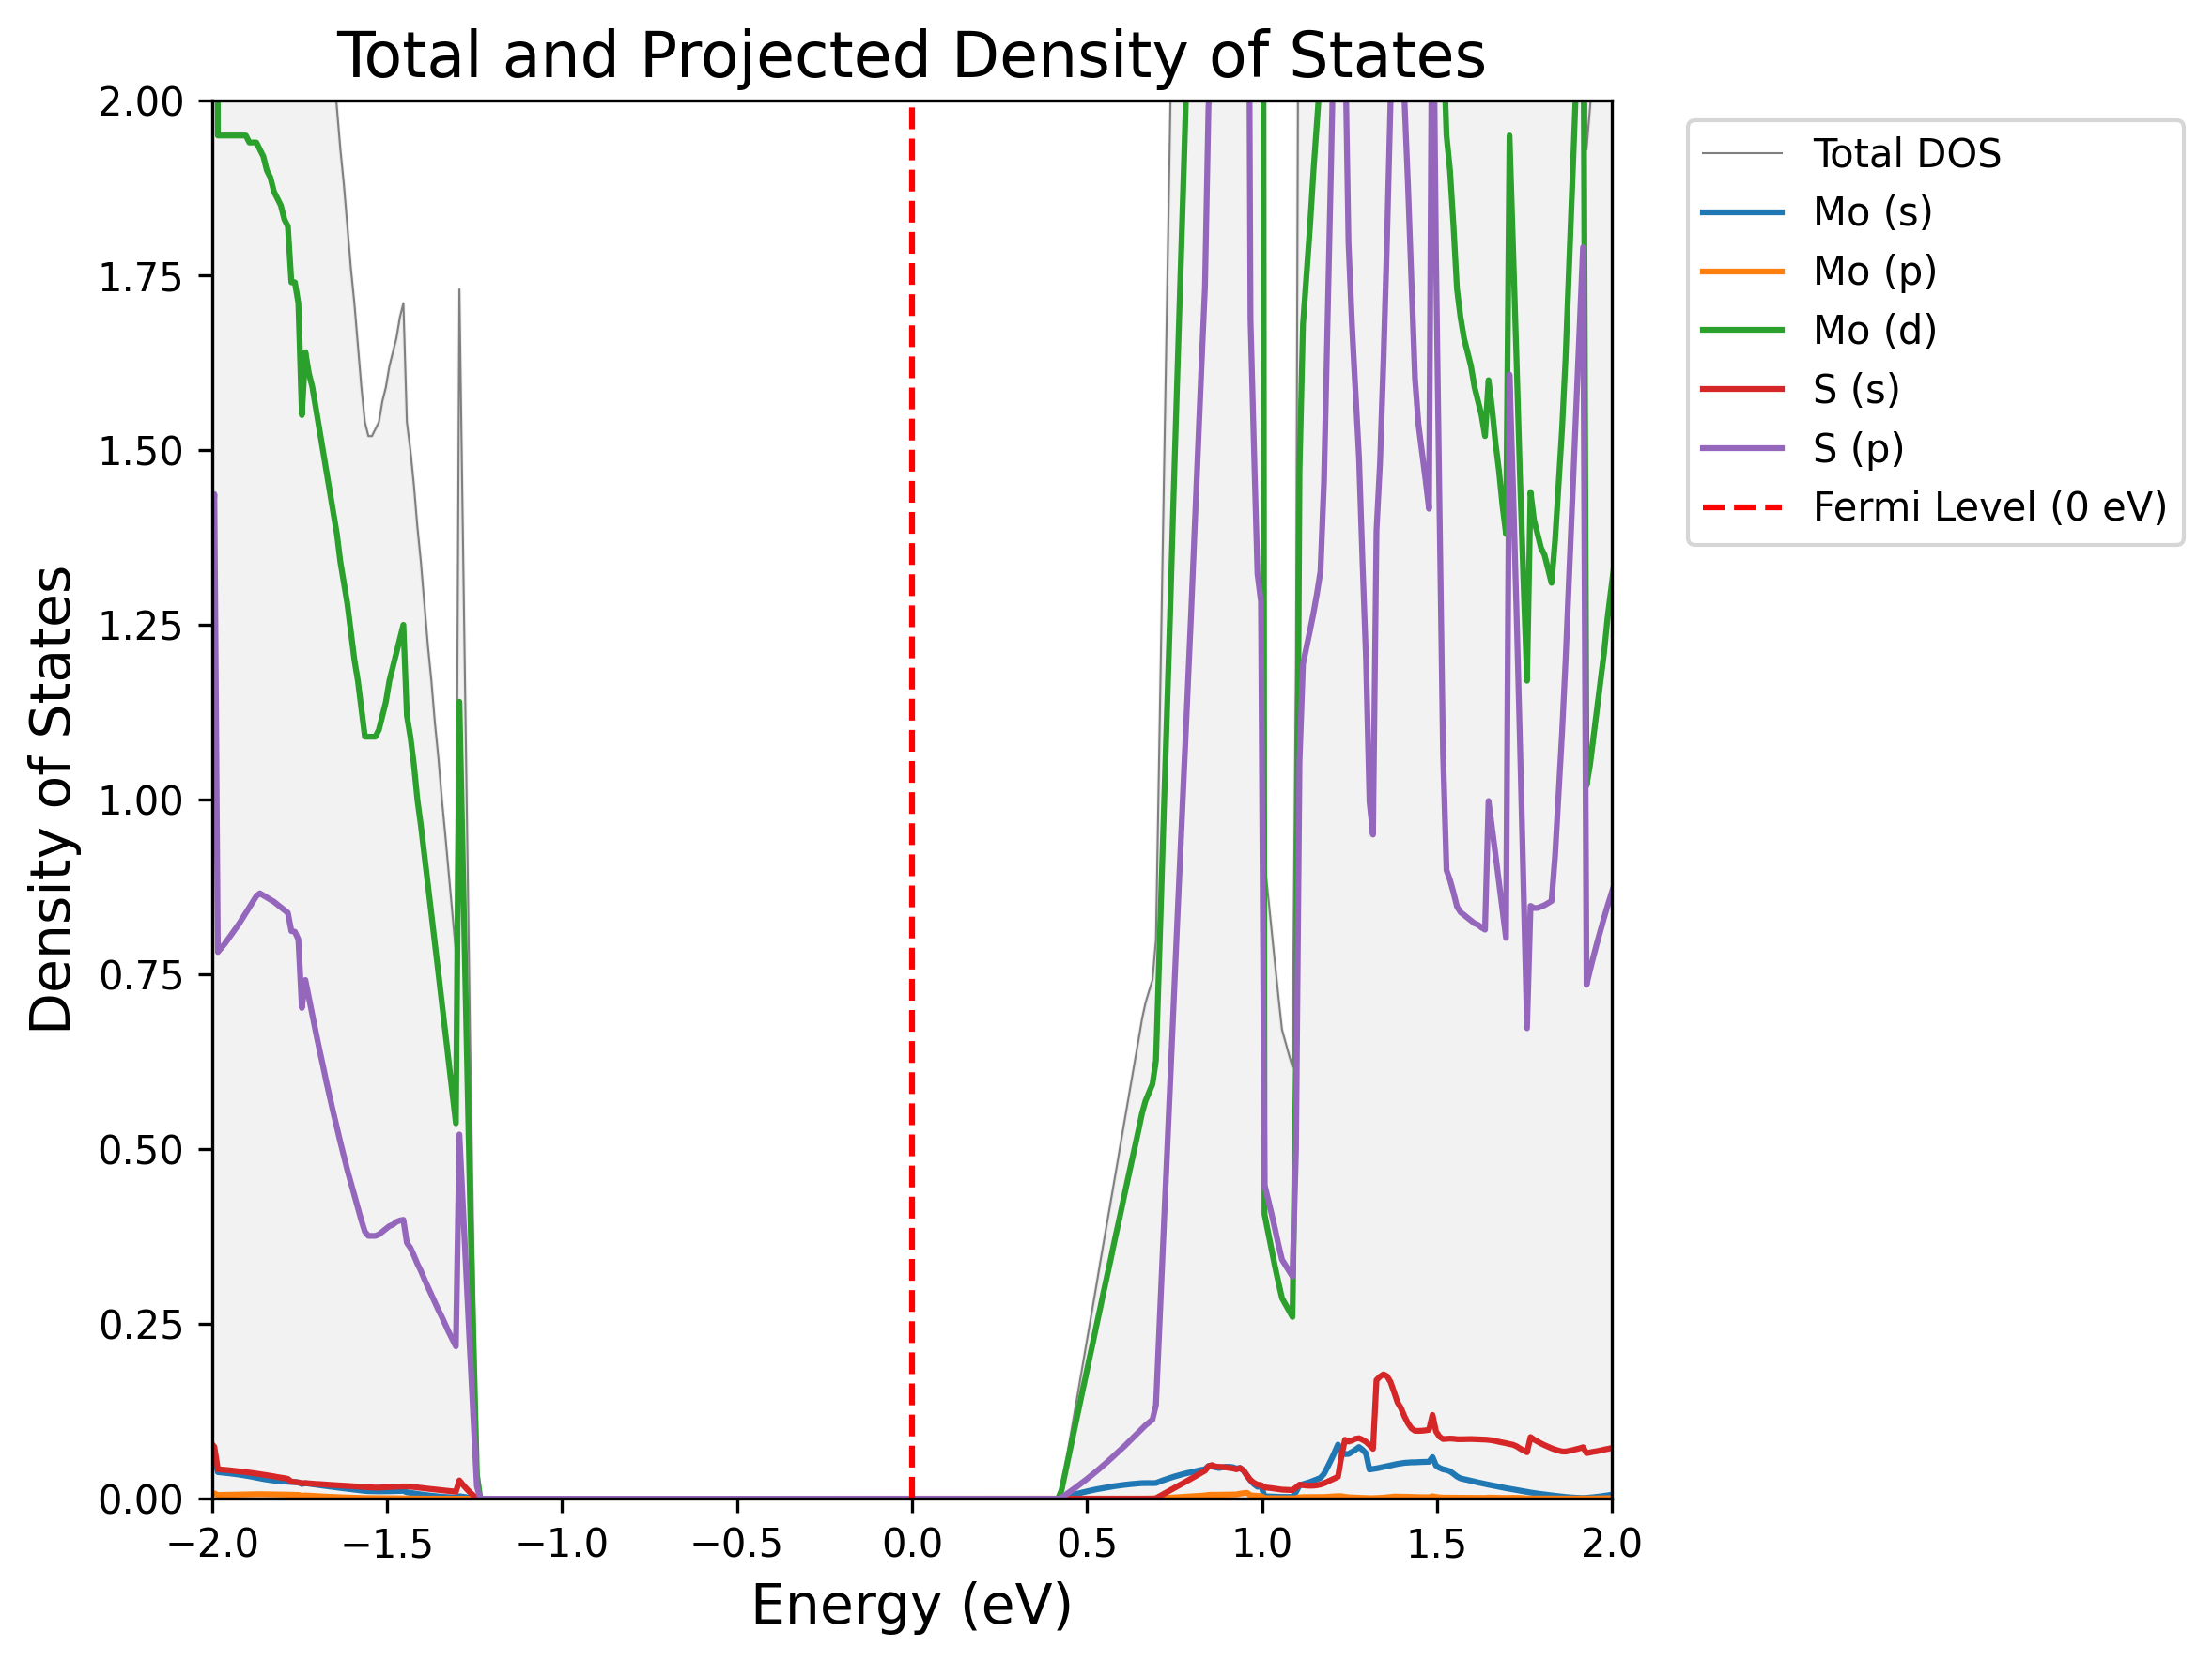

In [2]:
from workshop_tls import analyze_qe
analyze_qe("./ep3_dos_pdos/MoS2", "pdos", e_fermi=0.1899, xlim=[-2, 2], ylim=[0,2], save_as="pdos_plot.png")

<a id="convergence"></a>
## 📈 Plotting Convergence Tests

**Data file needed:** 2-column text file
- Column 1: Parameter being tested (e.g., cutoff energy)
- Column 2: Total Energy (Ry)

### Example: Cutoff Energy Convergence
```python
analyze_qe("calc-ecut.dat", "convergence", x_label="Wavefunction Cutoff (Ry)",
           save_as="ecut_convergence.png")
```

### Example: With a Custom X-axis Window
```python
analyze_qe("ecut.dat", "plot convergence", x_label="Cutoff (Ry)", xlim=[30, 80])
```

**Parameters:**
| Param | Meaning |
|---|---|
| `x_label` | Label for the X-axis (the tested parameter) |
| `xlim` | Restrict the X-axis range |
| `save_as` | Output image filename |

In [6]:
from workshop_tools import analyze_qe
analyze_qe("calc-ecut.dat", "convergence", x_label="Wavefunction Cutoff (Ry)", save_as="ecut_convergence.png")

Loading convergence data from calc-ecut.dat...
Error: Could not find 'calc-ecut.dat'.


In [ ]:
from workshop_tools import analyze_qe
analyze_qe("calc-kpoint.dat", "convergence", x_label="K-point convergence (Ry)", save_as="kpoint_convergence.png")

<a id="optics"></a>
## 🌈 Plotting Optical Properties

**Data files needed:**
1. `epsr_{prefix}.dat`
2. `epsi_{prefix}.dat`

```python
analyze_qe('crsi2n4', 'optics', c_supercell=20, t_effective=6.2,
           xlim=(0, 10), save_as='crsi2opticalgrid.png')
```

This computes and plots:
- Dielectric Function (real & imaginary)
- Absorption Coefficient
- Refractive Index
- Reflectivity

**Parameters:**
| Param | Meaning |
|---|---|
| `c_supercell` | Supercell size along the vacuum direction (Å) — used for 2D correction |
| `t_effective` | Effective slab thickness (Å) — used for 2D correction |
| `xlim` | Photon energy range (eV) to display |
| `save_as` | Output image filename |

In [ ]:
from workshop_tools import analyze_qe
analyze_qe('crsi2n4', 'optics', c_supercell=20, t_effective=6.2, xlim=(0, 10), save_as='crsi2opticalgrid.png')